In [1]:
import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
from sympy import sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

data = sio.loadmat('Xtrain.mat')
print(data['Xtrain'].shape)

series = np.array(data['Xtrain']).squeeze().astype(np.float32)
print(series.shape)
print(series[:10])

(1000, 1)
(1000,)
[ 86. 141.  95.  41.  22.  21.  32.  72. 138. 111.]


In [2]:
scaler = StandardScaler()

series_scaled = scaler.fit_transform(series.reshape(-1, 1)).squeeze()

print("Scaled shape:", series_scaled.shape)

Scaled shape: (1000,)


In [3]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_size):
        self.series = series
        self.window_size = window_size

    def __len__(self):
        return len(self.series) - self.window_size

    def __getitem__(self, idx):
        x = self.series[idx : idx + self.window_size]
        y = self.series[idx + self.window_size]

        # GRU input shape: [seq_len, input_size]
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(-1)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y

In [4]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1, dropout=0.0):
        super(GRUModel, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: [batch_size, seq_len, input_size]
        out, hidden = self.gru(x)

        # 取最后一个时间步的 hidden state
        last_out = out[:, -1, :]

        y_pred = self.fc(last_out)

        return y_pred.squeeze(-1)

In [5]:
train_ratio = 0.8
split_idx = int(len(series_scaled) * train_ratio)

train_series = series_scaled[:split_idx]
val_series = series_scaled[split_idx:]

print("Train length:", len(train_series))
print("Val length:", len(val_series))

Train length: 800
Val length: 200


In [13]:
def train_gru(
    train_series,
    val_series,
    window_size=15,
    hidden_size=64,
    num_layers=1,
    lr=0.001,
    batch_size=64,
    epochs=100,
    patience=10
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    train_dataset = TimeSeriesDataset(train_series, window_size)
    val_dataset = TimeSeriesDataset(val_series, window_size)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = GRUModel(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=1
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * x_batch.size(0)

        avg_train_loss = total_train_loss / len(train_dataset)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)

                total_val_loss += loss.item() * x_batch.size(0)

        avg_val_loss = total_val_loss / len(val_dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.6f} "
            f"Val Loss: {avg_val_loss:.6f}"
        )

        # early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping.")
            break

    model.load_state_dict(best_model_state)

    return model, train_losses, val_losses, best_val_loss

In [14]:
window_size = 15

model, train_losses, val_losses, best_val_loss = train_gru(
    train_series=train_series,
    val_series=val_series,
    window_size=window_size,
    hidden_size=64,
    num_layers=1,
    lr=0.001,
    batch_size=64,
    epochs=100,
    patience=10
)

print("Best validation loss:", best_val_loss)

Using device: cpu
Epoch [1/100] Train Loss: 1.010195 Val Loss: 0.883906
Epoch [2/100] Train Loss: 0.928914 Val Loss: 0.782899
Epoch [3/100] Train Loss: 0.804690 Val Loss: 0.602495
Epoch [4/100] Train Loss: 0.560094 Val Loss: 0.197274
Epoch [5/100] Train Loss: 0.306624 Val Loss: 0.129091
Epoch [6/100] Train Loss: 0.240926 Val Loss: 0.085407
Epoch [7/100] Train Loss: 0.195129 Val Loss: 0.056796
Epoch [8/100] Train Loss: 0.177672 Val Loss: 0.077537
Epoch [9/100] Train Loss: 0.164298 Val Loss: 0.025354
Epoch [10/100] Train Loss: 0.150163 Val Loss: 0.058230
Epoch [11/100] Train Loss: 0.145134 Val Loss: 0.028357
Epoch [12/100] Train Loss: 0.134507 Val Loss: 0.026570
Epoch [13/100] Train Loss: 0.132396 Val Loss: 0.015088
Epoch [14/100] Train Loss: 0.118106 Val Loss: 0.022833
Epoch [15/100] Train Loss: 0.115530 Val Loss: 0.048992
Epoch [16/100] Train Loss: 0.134535 Val Loss: 0.033454
Epoch [17/100] Train Loss: 0.113893 Val Loss: 0.017589
Epoch [18/100] Train Loss: 0.101225 Val Loss: 0.009667
E

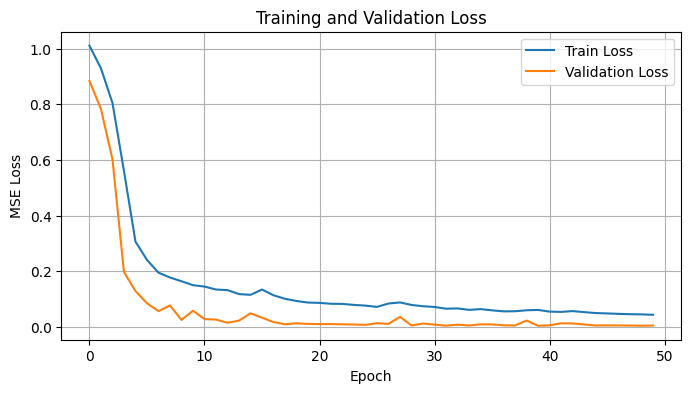

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
def predict_one_step(model, series_scaled, window_size):
    device = next(model.parameters()).device
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for i in range(len(series_scaled) - window_size):
            x = series_scaled[i : i + window_size]
            y_true = series_scaled[i + window_size]

            x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)

            y_pred = model(x_tensor).item()

            preds.append(y_pred)
            targets.append(y_true)

    preds = np.array(preds)
    targets = np.array(targets)

    return preds, targets

In [16]:
val_preds_scaled, val_targets_scaled = predict_one_step(
    model=model,
    series_scaled=val_series,
    window_size=window_size
)

# scale back
val_preds = scaler.inverse_transform(val_preds_scaled.reshape(-1, 1)).squeeze()
val_targets = scaler.inverse_transform(val_targets_scaled.reshape(-1, 1)).squeeze()

mae = mean_absolute_error(val_targets, val_preds)
mse = mean_squared_error(val_targets, val_preds)

print("Validation MAE:", mae)
print("Validation MSE:", mse)

Validation MAE: 2.553795883028284
Validation MSE: 11.486978296792547


In [11]:
val_preds_scaled, val_targets_scaled = predict_one_step(
    model=model,
    series_scaled=val_series,
    window_size=window_size
)

# scale back
val_preds = scaler.inverse_transform(val_preds_scaled.reshape(-1, 1)).squeeze()
val_targets = scaler.inverse_transform(val_targets_scaled.reshape(-1, 1)).squeeze()

mae = mean_absolute_error(val_targets, val_preds)
mse = mean_squared_error(val_targets, val_preds)

print("Validation MAE:", mae)
print("Validation MSE:", mse)

Validation MAE: 1.5048155600497382
Validation MSE: 4.307295050017454


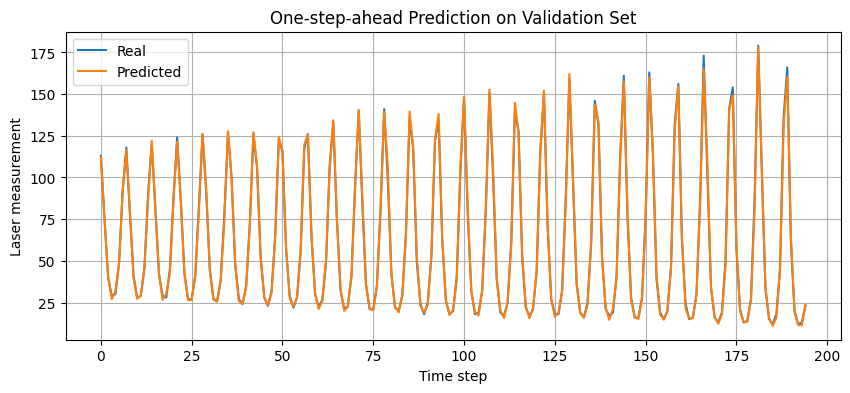

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(val_targets, label="Real")
plt.plot(val_preds, label="Predicted")
plt.xlabel("Time step")
plt.ylabel("Laser measurement")
plt.title("One-step-ahead Prediction on Validation Set")
plt.legend()
plt.grid(True)
plt.show()